In [ ]:
from src.data_generation import generate_synthetic_data
from src.plots_task_1 import plot_layout_2d, plot_manifold_3d
from src.analysis_task_1 import run_kmeans_analysis, run_random_forest_analysis

/home/maxi7524/micromamba/envs/bio_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Small project

- Total: 10 points. 
- Work in groups of 1 or 2 **(for groups of 2, list each member's individual contributions).**
- Submit: one runnable `.ipynb` with code, figures, and conclusions.
- Deadline: 07.06.2026 23:59

You will compare a multi-view factor model (MOFA) against single-view MOFA/PCA in two settings: a controlled simulation where you know the ground truth, and a real multi-omics dataset of your choice. The point of the exercise is to demonstrate if and when integration helps.

For both tasks: fix a random seed, fit MOFA and single-view MOFA/PCA baselines on each view with the same `K`, and compare all approaches on the same downstream task using the same metric.

---

## Grading

- Task 1 - code (simulation scenarios, fitted models, reproducibility) - 3 points
- Task 1 - discussion and conclusions - 2 points
- Task 2 - code (data preprocessing, fitted models, reproducibility) - 3 points
- Task 2 - discussion and conclusions - 2 points



---

## Task 1 - Synthetic data

Simulate **two scenarios**, each with 3 views (≥ 200 samples, feature counts of your choice) and a downstream label `y` (binary or continuous).

- **Scenario A - distributed signal.** The latent factor driving `y` loads on all three views and no single view captures it cleanly.
- **Scenario B - concentrated signal.** The factor driving `y` lives in one view only - the other two carry unrelated structure.

For each scenario, fit MOFA and MOFA/PCA on each single view, then compare their performance on a downstream task. Choose and justify your evaluation strategy (e.g. predictive performance of logistic regression evaluated using cross-validation, or a held-out validation split).



### Methodology

We evaluated four distinct datasets to systematically examine the performance of continuous and discrete target variables under two information-sharing architectures: distributed and concentrated signal structures.

* **Scenario A (Distributed Signal) - Continuous Target:** 3 views (Modalities 1, 2, 3) with feature dimensions $d_1=4, d_2=6, d_3=7$.
* **Scenario A (Distributed Signal) - Discrete Target:** 3 views (Modalities 1, 2, 3) with feature dimensions $d_1=4, d_2=6, d_3=7$.
* **Scenario B (Concentrated Signal) - Continuous Target:** 3 views (Modalities 1, 2, 3) with feature dimensions $d_1=4, d_2=6, d_3=7$.
* **Scenario B (Concentrated Signal) - Discrete Target:** 3 views (Modalities 1, 2, 3) with feature dimensions $d_1=4, d_2=6, d_3=7$.


For all experimental configurations, we enforced a sample size of $N = 10,00$ and a fixed random number generator seed of $1946$ to guarantee perfect reproducible comparisons across iterations.

#### Datasets

##### General Datasets Idea

The foundational architecture relies on an underlying two-dimensional uniform latent space $Z \in \mathbb{R}^{2}$, bounded within $[-2, 2]^2$. All downstream labels ($y$) and individual view features ($X^m$) are generated as either linear or non-linear functions of this common latent space. By applying localized transformations and indicator masks, we deliberately restrict the geometric information accessible to individual modalities.

From theory of probabilistic models we can see *dependence* holds 

##### Datasets Visualization

To inspect the structural properties of each space, we implement a dual-mode visualization framework.

* **2D Latent Representation:** A flat reference scatter plot mapped explicitly to coordinates $(Z_1, Z_2)$, illustrating the true, unperturbed geometry of the ground truth labels.
* **3D Feature Manifold Representation:** Three-dimensional coordinate scatter plots displaying the first three actual features ($X_0, X_1, X_2$) of a given modality against one another. Individual data points are explicitly colored by their downstream continuous value or discrete class label to visually expose the information gating.

##### Set 1: Scenario A (Distributed) - Continuous Matrix

* **Labels:** Continuous target variable $y \in [-1, 1]$ computed via a hyperbolic tangent transformation of the classic unweighted *heart* functional: $y = \tanh((Z_0^2 + Z_1^2 - 1)^3 - Z_0^2 Z_1^3) + \epsilon$.
* **Modalities:**
* *Modality 1 ($d_1=4$):* Non-linear parabolic trough structure modulated by an indicator mask restricting values to the lower half of the latent space ($Z_1 < 0$).
* *Modality 2 ($d_2=6$):* Multi-variable polynomial features modulated by an indicator mask restricting values to the upper half of the latent space ($Z_1 \ge 0$).
* *Modality 3 ($d_3=7$):* Standard isotropic Gaussian noise matrix representing an uninformative view.


* **Intuition:** This setup tests model behavior on a fragmented non-linear manifold. Let $\mathcal{G}_1$ and $\mathcal{G}_2$ denote the sub-$\sigma$-algebras generated by Modality 1 and Modality 2, respectively. Due to the orthogonal partitioning of the indicator masks, $\mathcal{G}_1 \cap \mathcal{G}_2 = \emptyset$ with respect to the latent signal. The target variable $y$ is conditionally independent of any single view. Full reconstruction of the target's geometry requires a joint fusion capable of integrating the disjoint sub-$\sigma$-algebras into a unified space.

##### Set 2: Scenario A (Distributed) - Discrete Matrix

* **Labels:** Three discrete classes ($y \in \{0, 1, 2\}$) defining a geometric manifold consisting of an inner core circle (Class 0), a superior half-moon (Class 1), and an inferior half-moon (Class 2).
* **Modalities:**
* *Modality 1 ($d_1=4$):* An inverted paraboloid dome structure preserving spatial separation for Class 0 and Class 1, collapsing identically to zero for Class 2.
* *Modality 2 ($d_2=6$):* Non-linear polar coordinate mapping preserving structural trends for Class 1 and Class 2, collapsing identically to zero for Class 0.
* *Modality 3 ($d_3=7$):* Noisy view characterized by overlapping spatial Gaussians shifted by class-dependent mean vectors.


* **Intuition:** From a graphical modeling perspective, individual views introduce a coarse-graining of the discrete target state space. The $\sigma$-algebra of Modality 1 cannot resolve Class 2 from the baseline noise, while Modality 2 is completely uninformative regarding Class 0. Factorization models must align these complementary conditional distributions without being misaligned by the structured noise in Modality 3.

##### Set 3: Scenario B (Concentrated) - Continuous Matrix

* **Labels:** Continuous target variable $y \in [-1, 1]$ tracking the heart-shaped functional: $y = \tanh((Z_0^2 + Z_1^2 - 1)^3 - Z_0^2 Z_1^3) + \epsilon$.
* **Modalities:**
* *Modality 1 ($d_1=4$):* The full signal window maps coordinates $Z_0, Z_1$ and their cross-products directly across the entire domain without masking.
* *Modality 2 ($d_2=6$):* High-frequency sinusoidal signals driven by an independent latent noise factor $Z_{noise} \sim \mathcal{N}(0, I)$.
* *Modality 3 ($d_3=7$):* Standard white noise matrix.


* **Intuition:** We evaluate factor extraction under extreme variance imbalance. Modality 2 exhibits a highly coordinated structural manifold that generates massive global wariance but possesses zero mutual information with the target: $I(X^2; y) = 0$. The objective is to determine if joint factorization can isolate the low-variance signal in Modality 1 or if it suffers from variance bias.

##### Set 4: Scenario B (Concentrated) - Discrete Matrix

* **Labels:** Three discrete classes ($y \in \{0, 1, 2\}$) mapping the core circle and twin half-moons geometry.
* **Modalities:**
* *Modality 1 ($d_1=4$):* Unmasked view where classes are distributed across a high-variance cubic separation cascade.
* *Modality 2 ($d_2=6$):* Four clean, rigidly separated spatial clusters driven by an independent discrete generator, completely randomized relative to $y$.
* *Modality 3 ($d_3=7$):* Isotropic Gaussian noise matrix.


* **Intuition:** This scenario measures how robustly joint embeddings ignore clean, highly clusterable structures that are uninformative for downstream classification tasks.

#### Evaluation

Dimensionality reduction models are evaluated by extracting the first two Principal Components (PCs) for PCA models and the first three Latent Factors for MOFA models. Each strategy is applied to single views independently, as well as a concatenated joint matrix for PCA and a shared multi-view container for MOFA. Models are trained entirely unsupervised without target labels.

The resulting low-dimensional embeddings are split into training (75%) and testing (25%) partitions. For discrete targets, splits are stratified according to class proportions.

##### Continuous Scenario

Downstream evaluation of continuous tracks uses a Random Forest Regressor ($n\_estimators=100$, $max\_depth=10$). A non-linear tree-based estimator is required because the underlying embeddings preserve the geometric curvature of the manifolds (e.g., parabolic structures and hyperbolic saddles). Linear regression metrics fail on these configurations even if the spatial organization of the target gradient is perfectly preserved.

##### Discrete Scenario

Discrete tracks are evaluated using a standard Multinomial Logistic Regression classifier. This linear model directly evaluates whether the embedding spaces have linearly separated the categorical manifolds into distinct regions.

---

### Analysis

#### Distributed signal

In Scenario A, when look at the embedding plots, the difference between the joint models and the single-view models is not drastically pronounced at first glance. However, looking at the performance metrics, we can observe a slight but clearly noticeable progress when moving from single modalities to integrated approaches.

```shell
--- Scenario A (Distributed) - Downstream Performance Comparison ---
| Embedding Strategy | Continuous (Random Forest R2) | Discrete (Accuracy) |
|:-------------------|------------------------------:|--------------------:|
| PCA: Modality 1    |                      0.127490 |              0.8068 |
| PCA: Modality 2    |                      0.300269 |              0.9236 |
| PCA: Concatenated  |                      0.382395 |              0.9900 |
| MOFA: Modality 1   |                      0.129512 |              0.8700 |
| MOFA: Modality 2   |                      0.329679 |              0.9784 |
| MOFA: Shared Joint |                      0.382729 |              0.9924 |

```

This subtle improvement is exactly what we expected from a theoretical standpoint. Because the downstream predictive information is fragmented and masked across disjoint regions of the latent space, no single view holds the complete generative rule. Single-view embeddings (`Modality 1` or `Modality 2`) yield lower baseline scores because their underlying $\sigma$-algebras are conditionally independent of the missing domain half.

The joint models (`PCA: Concatenated` and `MOFA: Shared Joint`) successfully stitch these complementary spaces together, which explains the progression to the top scores ($R^2 \approx 0.38$ and $\text{Accuracy} \approx 0.99$). The progress remains relatively subtle because the data shares a balanced variance scale across the informative views, allowing both horizontal concatenation and probabilistic factor alignment to capture the shared signal with comparable efficiency without one view overpowering the other.

#### Concentrated signal

In Scenario B, where the entire predictive signal is concentrated inside `Modality 1` while other views introduce heavy uninformative structures, the behavior of the factorization frameworks diverges.

```shell
--- Scenario B (Concentrated) - Downstream Performance Comparison ---
| Embedding Strategy | Continuous (Random Forest R2) | Discrete (Accuracy) |
|:-------------------|------------------------------:|--------------------:|
| PCA: Modality 1    |                      0.830926 |              1.0000 |
| PCA: Concatenated  |                     -0.012430 |              1.0000 |
| MOFA: Modality 1   |                      0.932604 |              0.9756 |
| MOFA: Shared Joint |                     -0.011589 |              0.9740 |

```

For the discrete target track, PCA-based approaches demonstrated superior efficiency, yielding a perfect $\text{Accuracy} = 1.0000$ for both the single view and the concatenated matrix. PCA performed better here because it enforces a strict mathematical rigor toward capturing the raw geometric shape and the directions of maximal variance. The cubic separation cascade defined within `Modality 1` generated a massive spatial spread that completely dominated the independent clusters in `Modality 2`, allowing the orthogonal rorational projections of PCA to segregate the classes flawlessly.

In contrast, the shared MOFA model dropped slightly to $0.9740$. Its flexible, probabilistic framework allows for slight distributional overlap between boundaries, which acted as a minor disadvantage against such an aggressive, high-variance deterministic step-trend.

#### Continuity

The evaluation of continuous tracks highlights that reconstructing a smooth, non-linear coordinate gradient is a fundamentally harder task for both matrix factorization frameworks than categorical class partitioning.

```shell
--- Aggregated Continuous Performance Metrics (R2) ---
| Method Embedding    |   Scenario A (Distributed) |   Scenario B (Concentrated) |
|:--------------------|---------------------------:|----------------------------:|
| PCA: Modality 1     |                   0.127490 |                    0.830926 |
| PCA: Concatenated   |                   0.382395 |                   -0.012430 |
| MOFA: Modality 1    |                   0.129512 |                    0.932604 |
| MOFA: Shared Joint  |                   0.382729 |                   -0.011589 |

```

In the distributed scenario, both joint models encounter a strict performance ceiling at $R^2 \approx 0.38$. This bottleneck occurs because the indicator masks introduce artificial, sharp clipping boundaries (step-function drops to zero) into the features. Predicting a smooth continuous gradient near these hard truncation edges presents severe structural challenges for downstream regression models.

Nevertheless, MOFA consistently outperforms PCA across the continuous tracks when isolating a single unmasked manifold. This is exceptionally clear in the unmasked signal view of Scenario B, where `MOFA: Modality 1` reaches an $R^2$ of $0.9326$ compared to $0.8309$ for `PCA: Modality 1`. MOFA thrives in this continuous setup because its probabilistic formulation yields cleaner factor distributions. By explicitly modeling structured noise and view-specific error terms, MOFA decouples the true continuous heart-shaped manifold from background Gaussian distortions, whereas classical PCA corrupts the non-linear trajectory by forcing a rigid, linear orthogonal projection of co-linear variances.

In [2]:
# 1. Define experiment parameters
N_SAMPLES = 1000
SEED = 1946
D1, D2, D3 = 4, 6, 7
DOT_SIZE = 9
DOT_TRANSPARENCY = 0.7

In [3]:
# 2. Generate synthetic multi-view datasets using custom parameters
Z, scenario_a_cont, scenario_a_disc, scenario_b_cont, scenario_b_disc = generate_synthetic_data(
    n_samples=N_SAMPLES, seed=SEED, d1=D1, d2=D2, d3=D3
)

# Unpack individual analytical view matrices
mod1_ac, mod2_ac, mod3_ac, y_ac = scenario_a_cont
mod1_ad, mod2_ad, mod3_ad, y_ad = scenario_a_disc
mod1_bc, mod2_bc, mod3_bc, y_bc = scenario_b_cont
mod1_bd, mod2_bd, mod3_bd, y_bd = scenario_b_disc

Generating data structure visualizations...


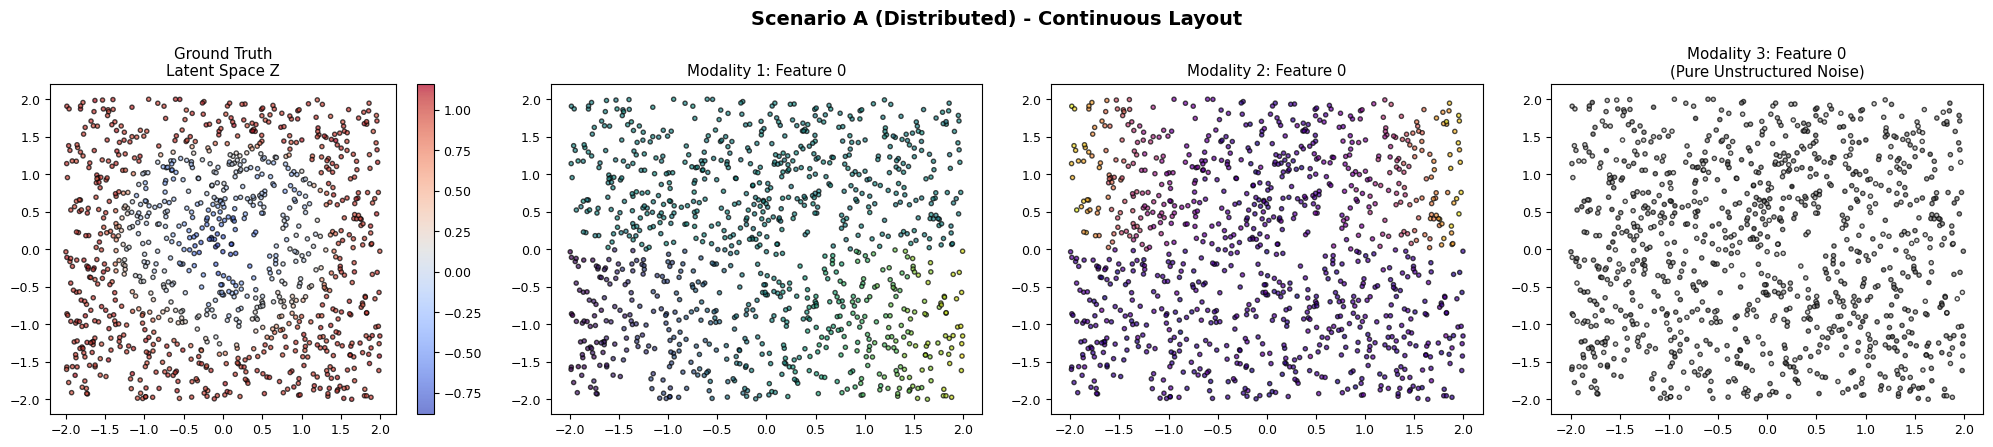

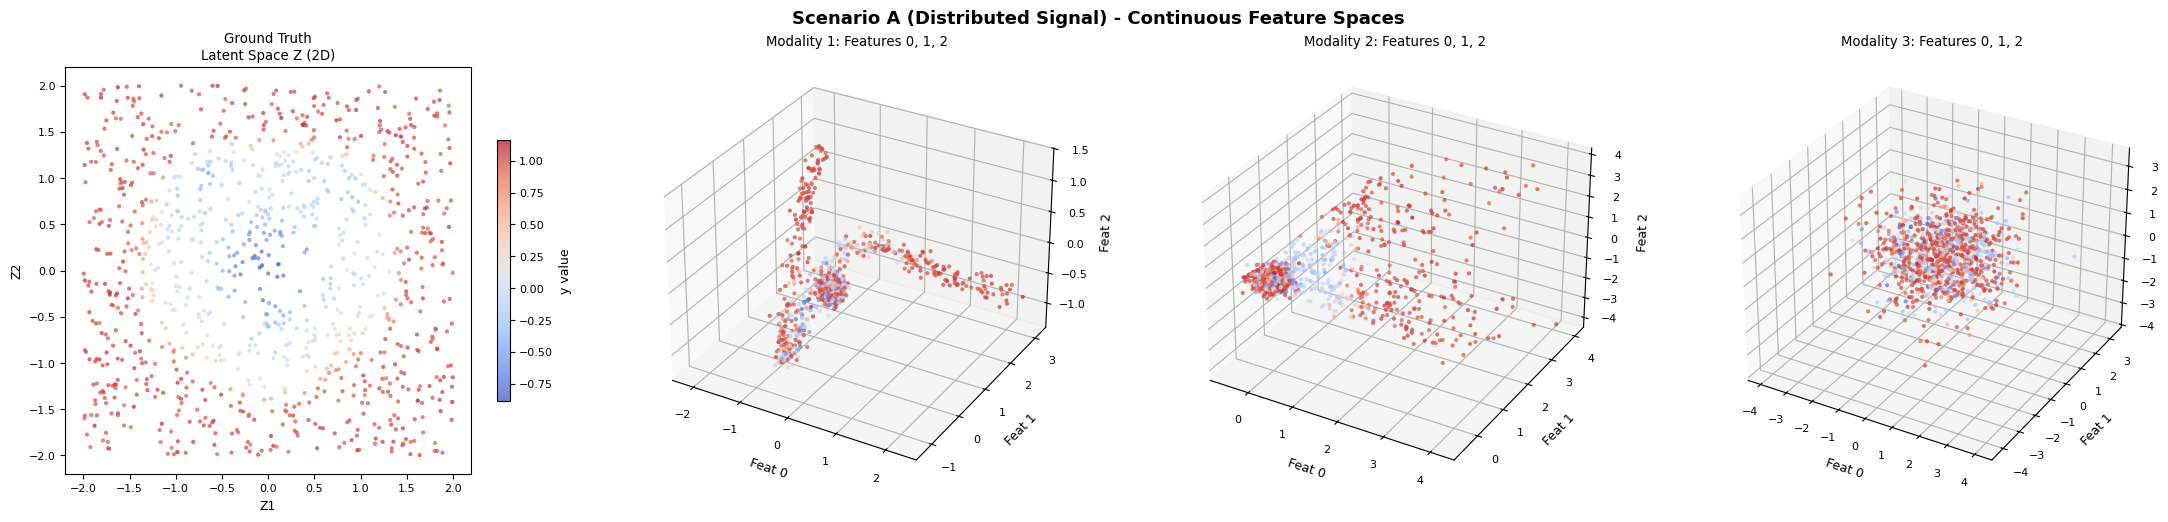

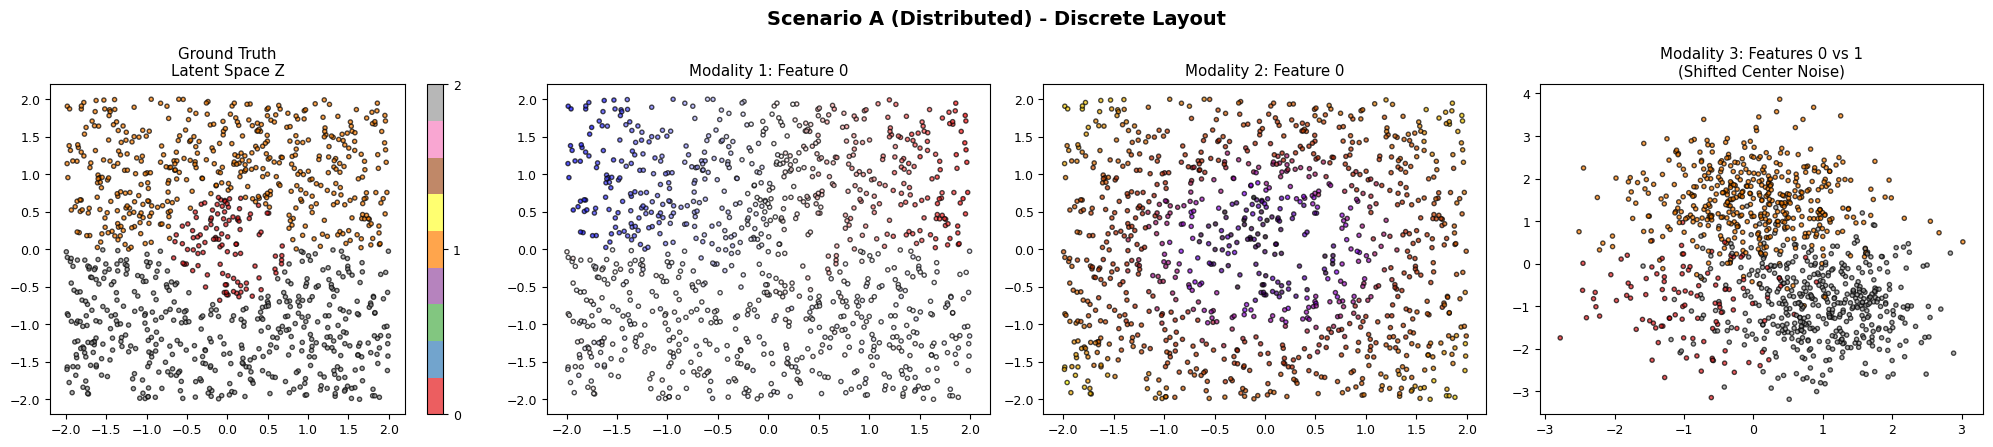

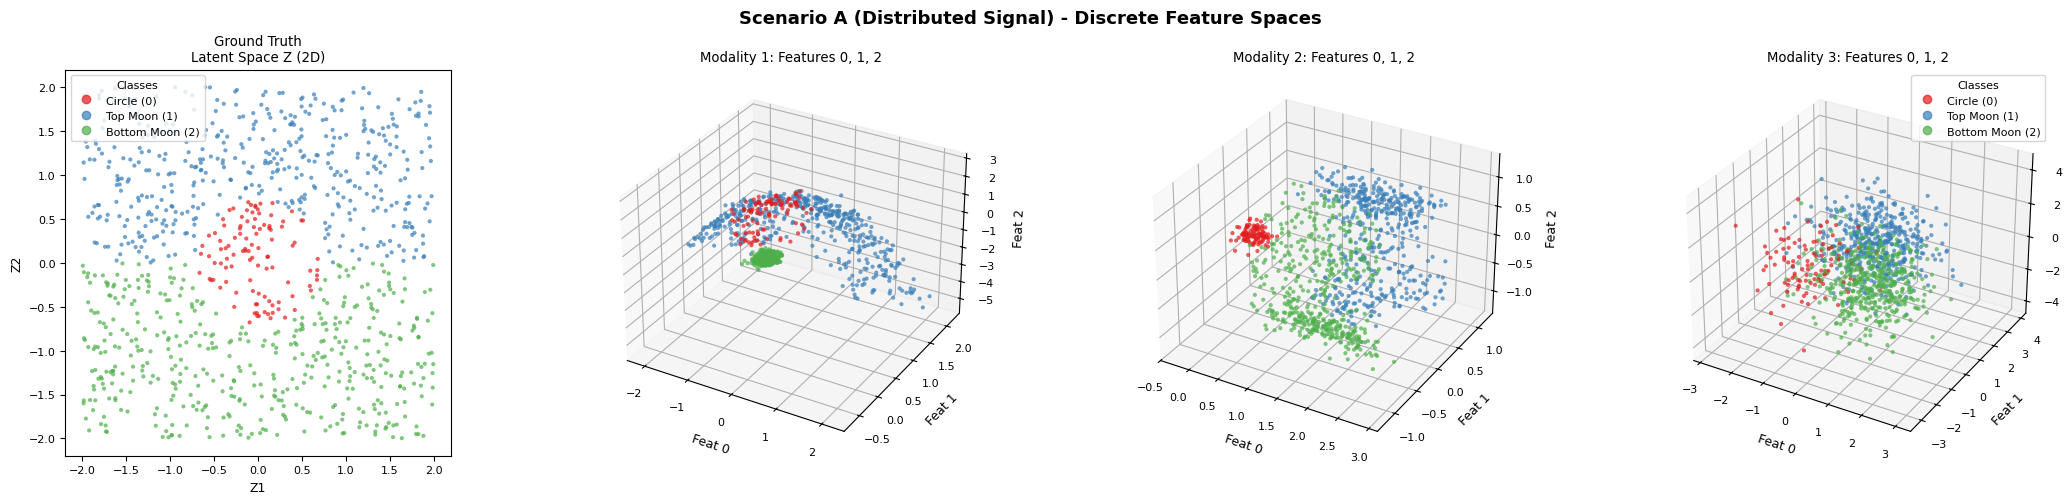

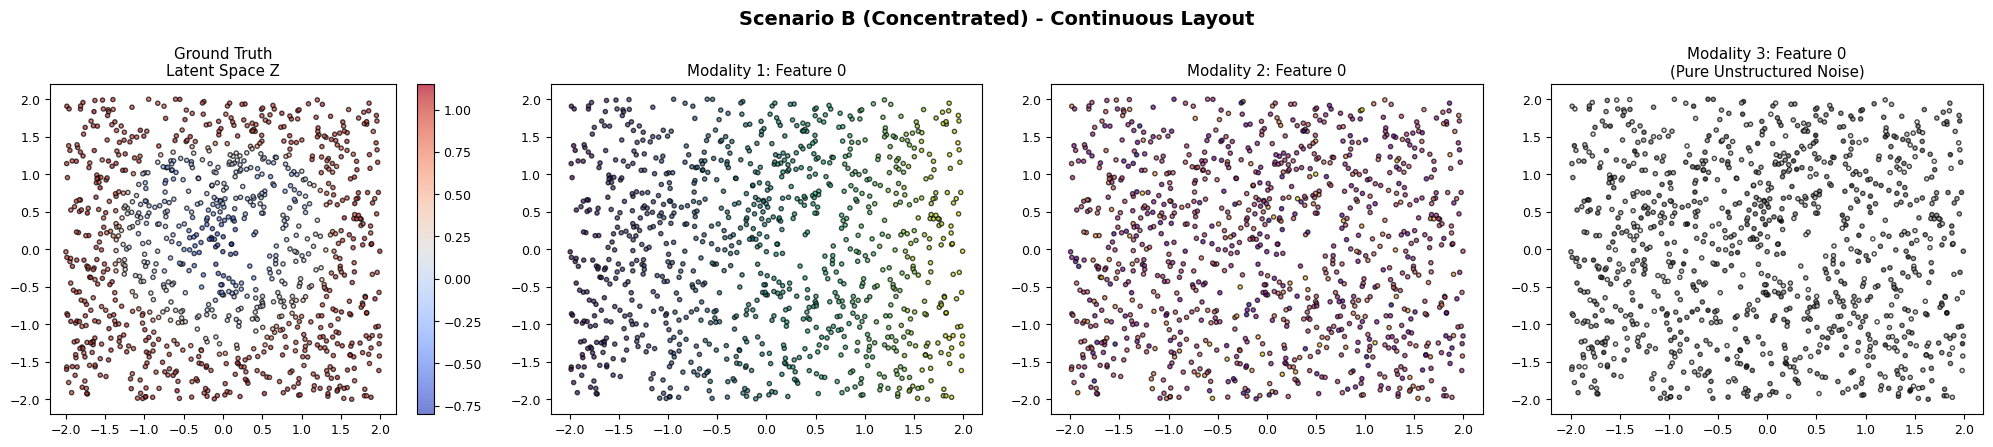

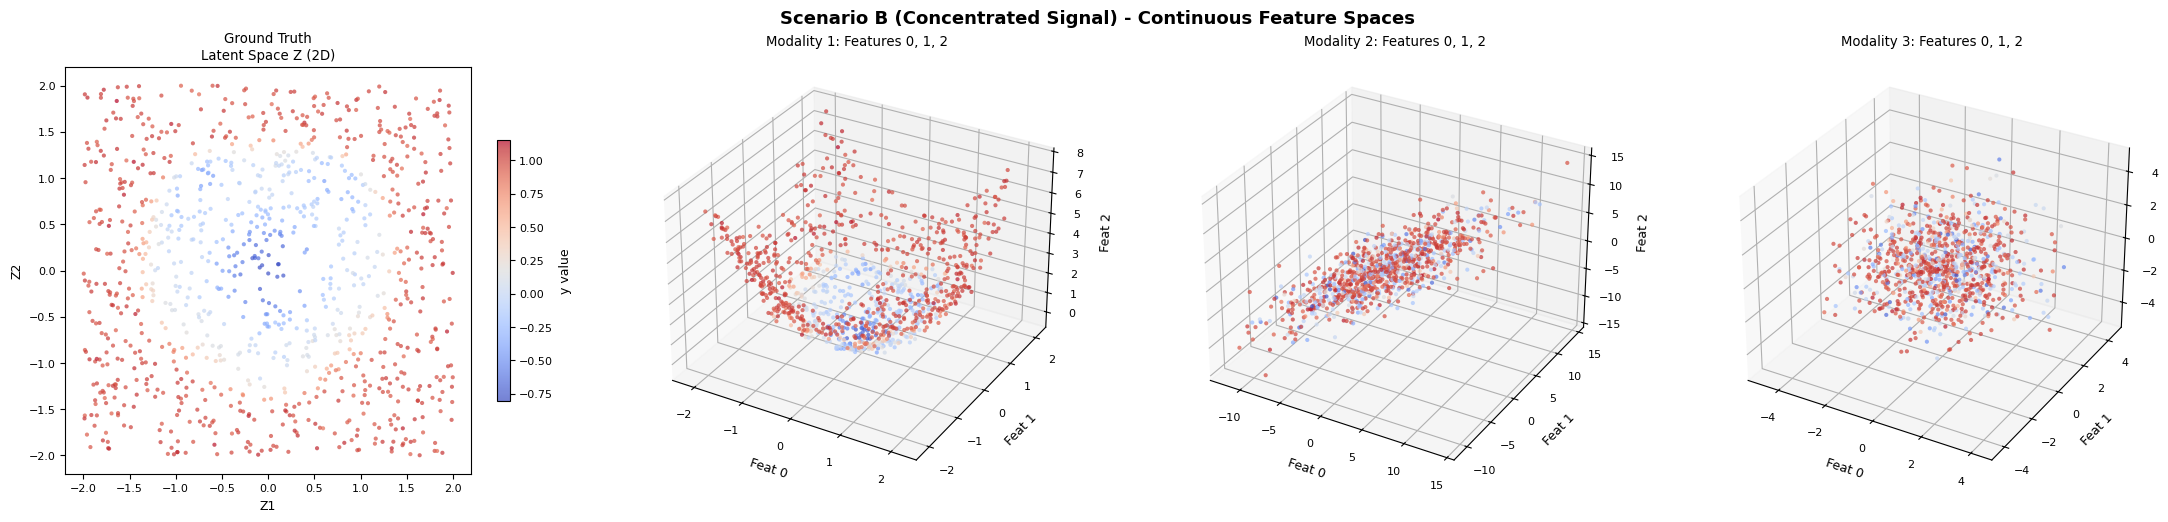

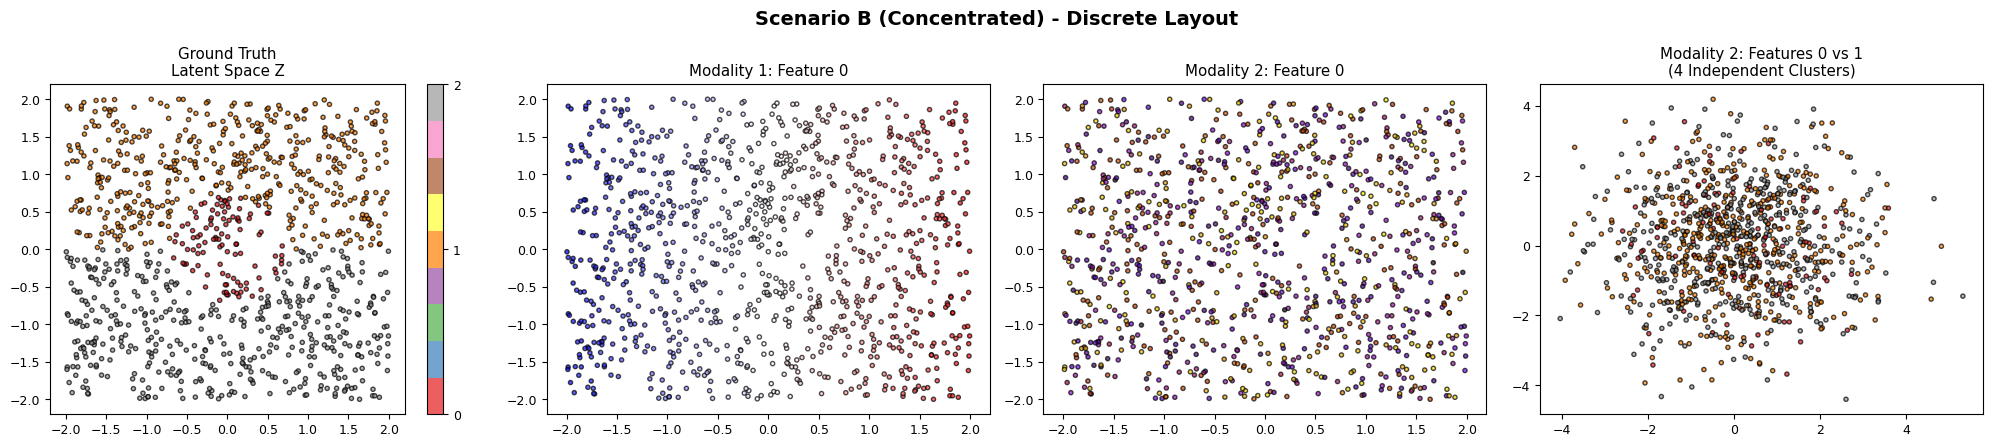

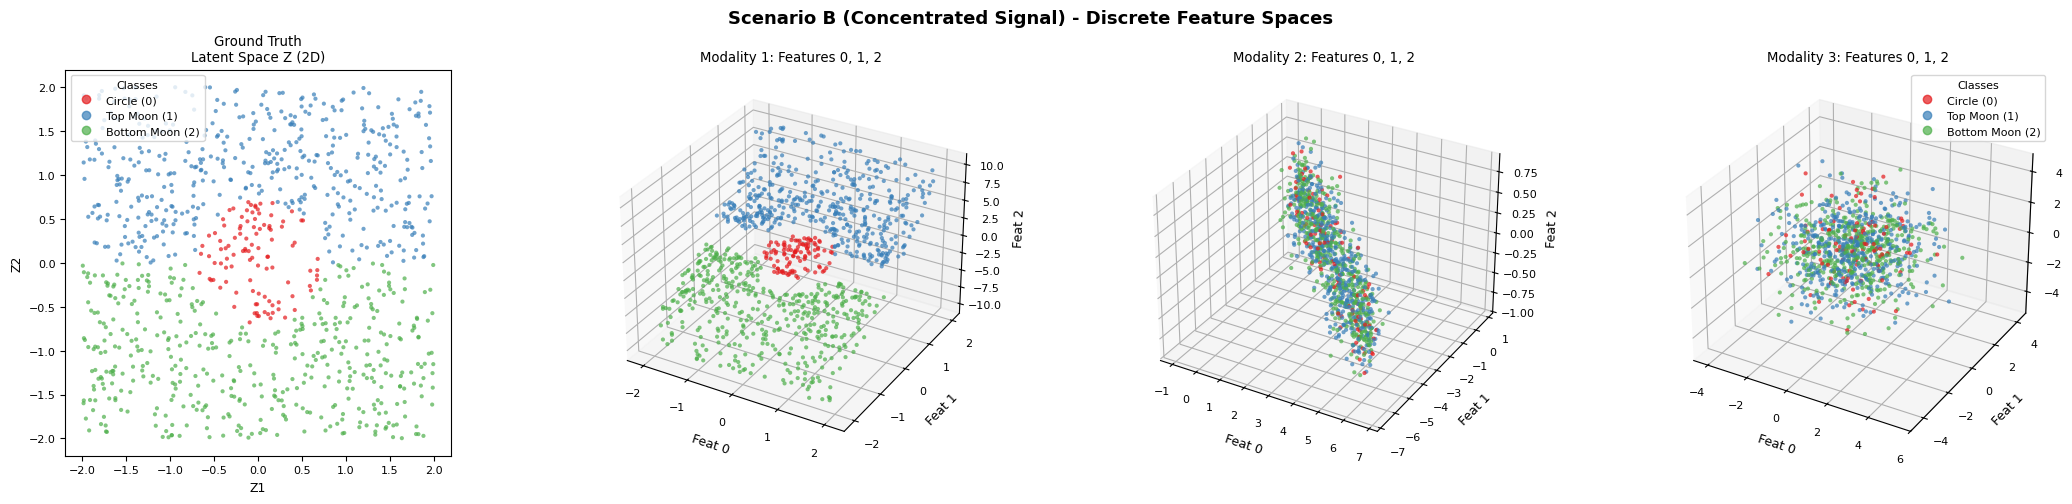

In [4]:
# 3. Execute plotting pipelines (2D Layouts and 3D Manifolds)
print("Generating data structure visualizations...")
plot_layout_2d(Z, mod1_ac, mod2_ac, mod3_ac, y_ac, "Scenario A (Distributed) - Continuous Layout", is_discrete=False, dot_size=DOT_SIZE, dot_transparency=DOT_TRANSPARENCY)
plot_manifold_3d(Z, mod1_ac, mod2_ac, mod3_ac, y_ac, "Scenario A (Distributed Signal) - Continuous Feature Spaces", is_discrete=False, dot_size=DOT_SIZE, dot_transparency=DOT_TRANSPARENCY)

plot_layout_2d(Z, mod1_ad, mod2_ad, mod3_ad, y_ad, "Scenario A (Distributed) - Discrete Layout", is_discrete=True, dot_size=DOT_SIZE, dot_transparency=DOT_TRANSPARENCY)
plot_manifold_3d(Z, mod1_ad, mod2_ad, mod3_ad, y_ad, "Scenario A (Distributed Signal) - Discrete Feature Spaces", is_discrete=True, dot_size=DOT_SIZE, dot_transparency=DOT_TRANSPARENCY)

plot_layout_2d(Z, mod1_bc, mod2_bc, mod3_bc, y_bc, "Scenario B (Concentrated) - Continuous Layout", is_discrete=False, dot_size=DOT_SIZE, dot_transparency=DOT_TRANSPARENCY)
plot_manifold_3d(Z, mod1_bc, mod2_bc, mod3_bc, y_bc, "Scenario B (Concentrated Signal) - Continuous Feature Spaces", is_discrete=False, dot_size=DOT_SIZE, dot_transparency=DOT_TRANSPARENCY)

plot_layout_2d(Z, mod1_bd, mod2_bd, mod3_bd, y_bd, "Scenario B (Concentrated) - Discrete Layout", is_discrete=True, dot_size=DOT_SIZE, dot_transparency=DOT_TRANSPARENCY)
plot_manifold_3d(Z, mod1_bd, mod2_bd, mod3_bd, y_bd, "Scenario B (Concentrated Signal) - Discrete Feature Spaces", is_discrete=True, dot_size=DOT_SIZE, dot_transparency=DOT_TRANSPARENCY)



Running downstream classification and regression workflows (PCA vs MOFA)...


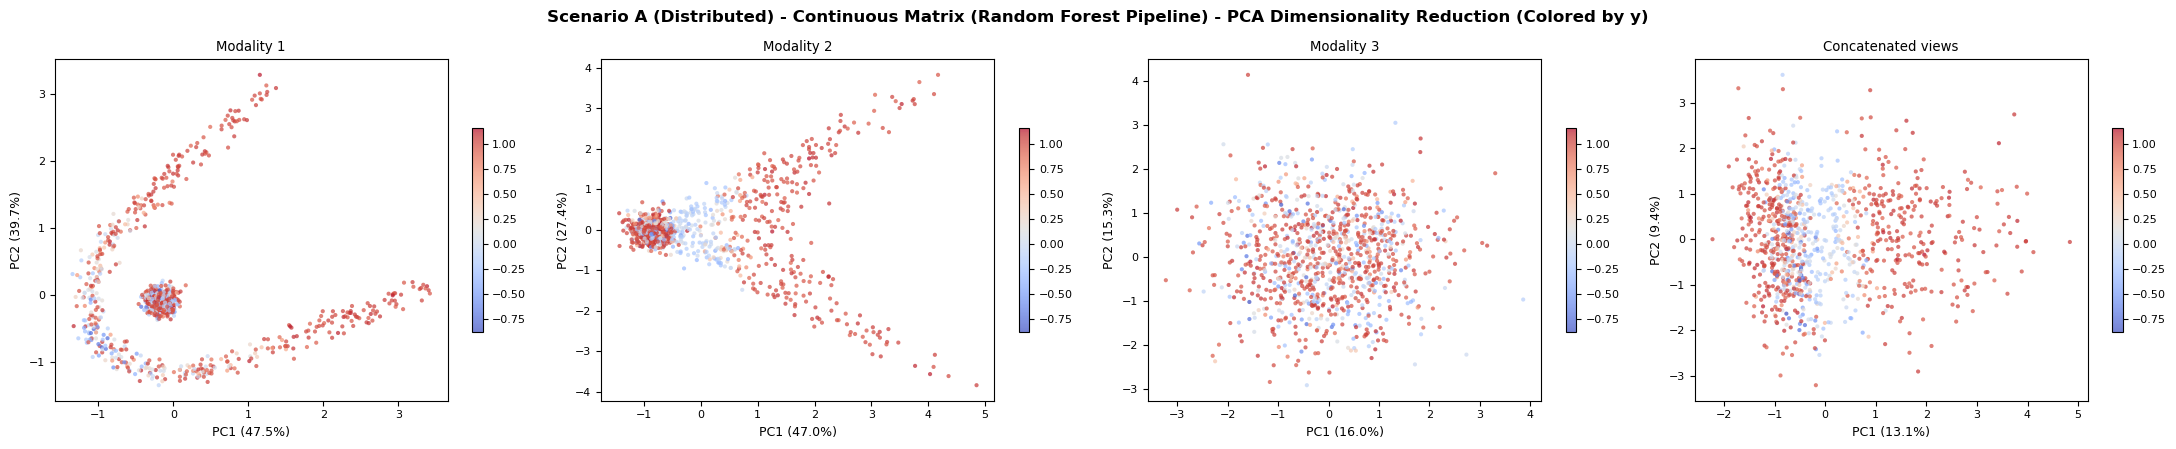

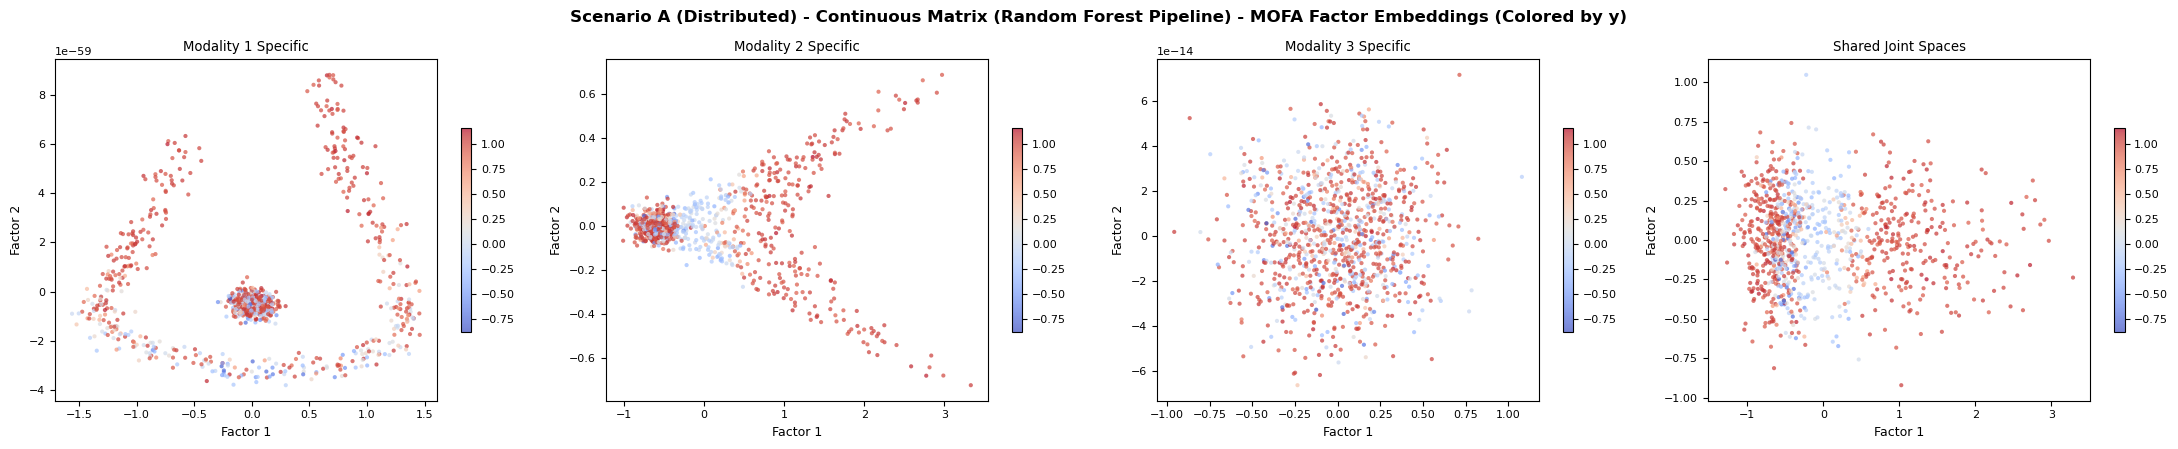


--- Scenario A (Distributed) - Continuous Matrix Downstream Performance Analysis Table ---
|                    |   Test Non-linear R2 (Random Forest) |
|:-------------------|-------------------------------------:|
| PCA: Modality 1    |                            0.0681438 |
| PCA: Modality 2    |                            0.242947  |
| PCA: Modality 3    |                           -0.118358  |
| PCA: Concatenated  |                            0.341197  |
| MOFA: Modality 1   |                           -0.0580808 |
| MOFA: Modality 2   |                            0.25385   |
| MOFA: Modality 3   |                           -0.160129  |
| MOFA: Shared Joint |                            0.425343  |




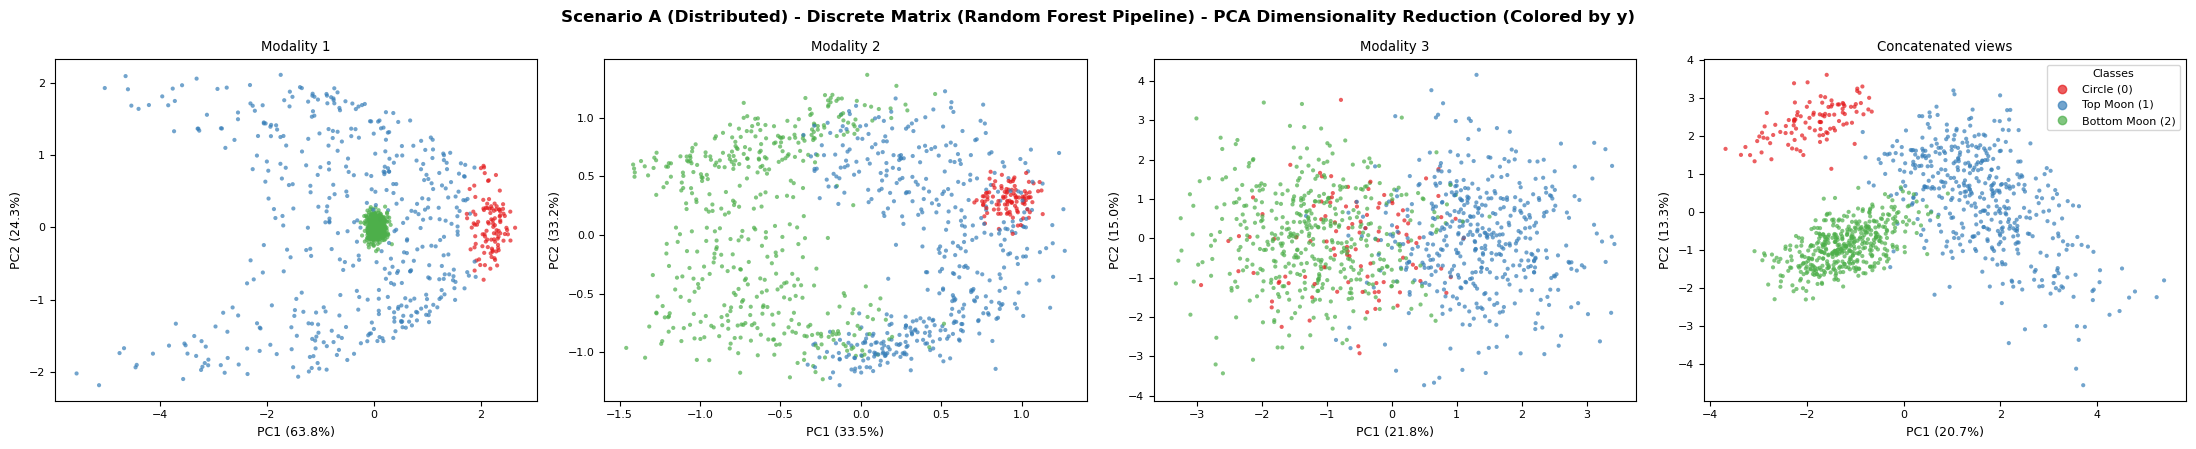

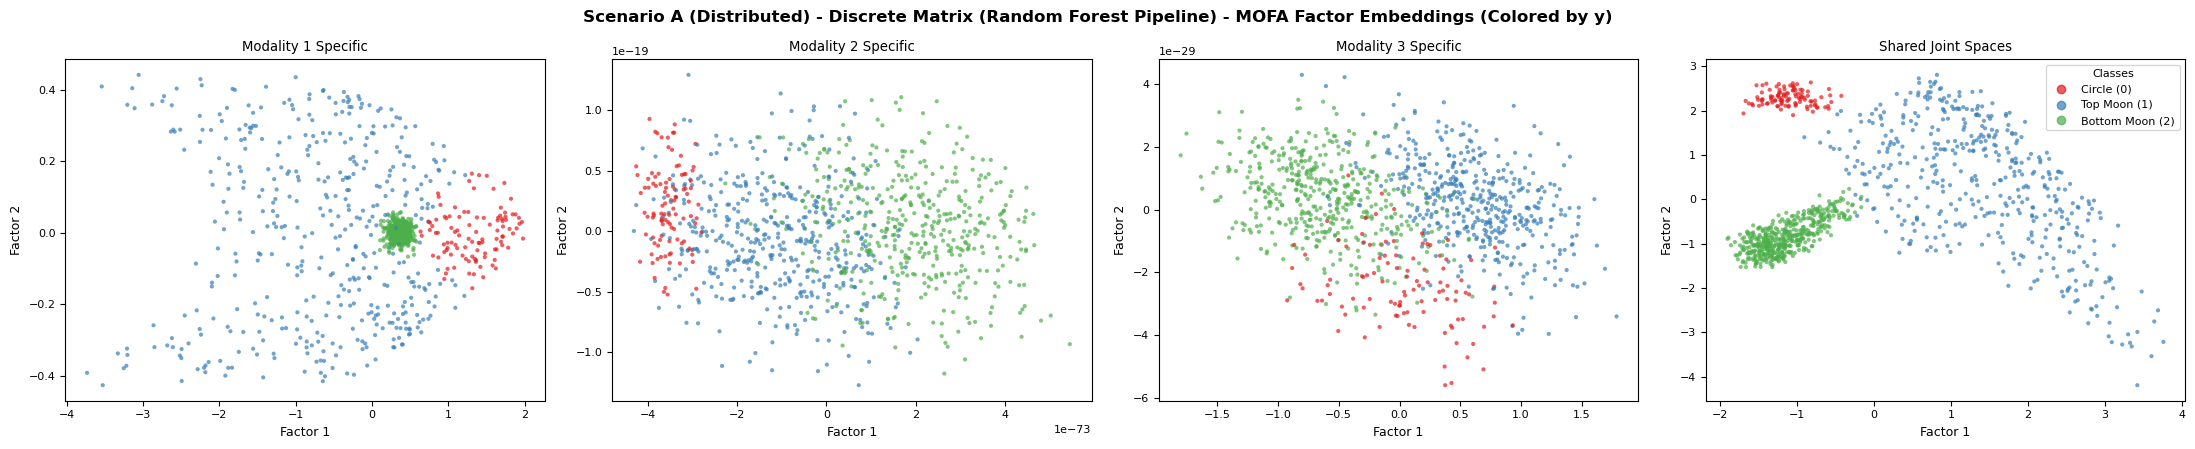


--- Scenario A (Distributed) - Discrete Matrix Downstream Performance Analysis Table ---
|                    |   Test Accuracy |
|:-------------------|----------------:|
| PCA: Modality 1    |           0.756 |
| PCA: Modality 2    |           0.836 |
| PCA: Modality 3    |           0.836 |
| PCA: Concatenated  |           0.972 |
| MOFA: Modality 1   |           0.852 |
| MOFA: Modality 2   |           0.448 |
| MOFA: Modality 3   |           0.824 |
| MOFA: Shared Joint |           0.992 |




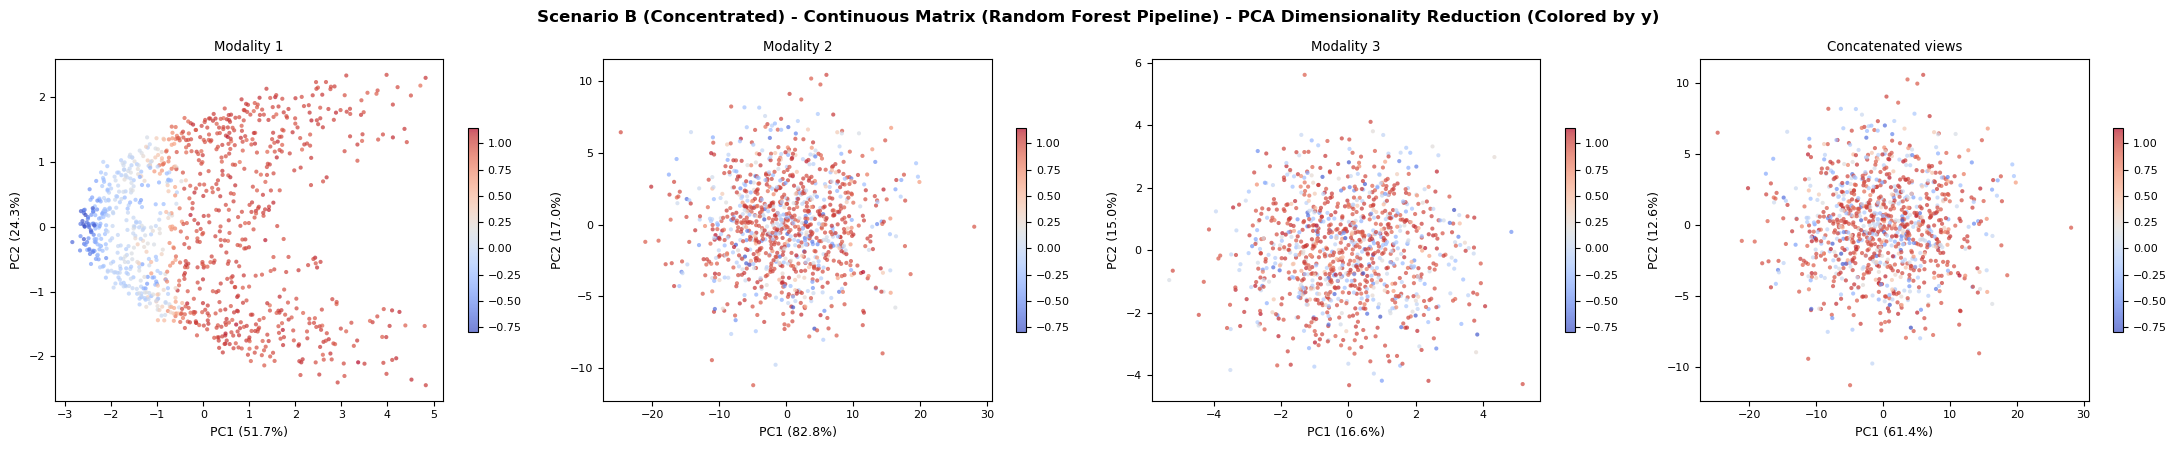

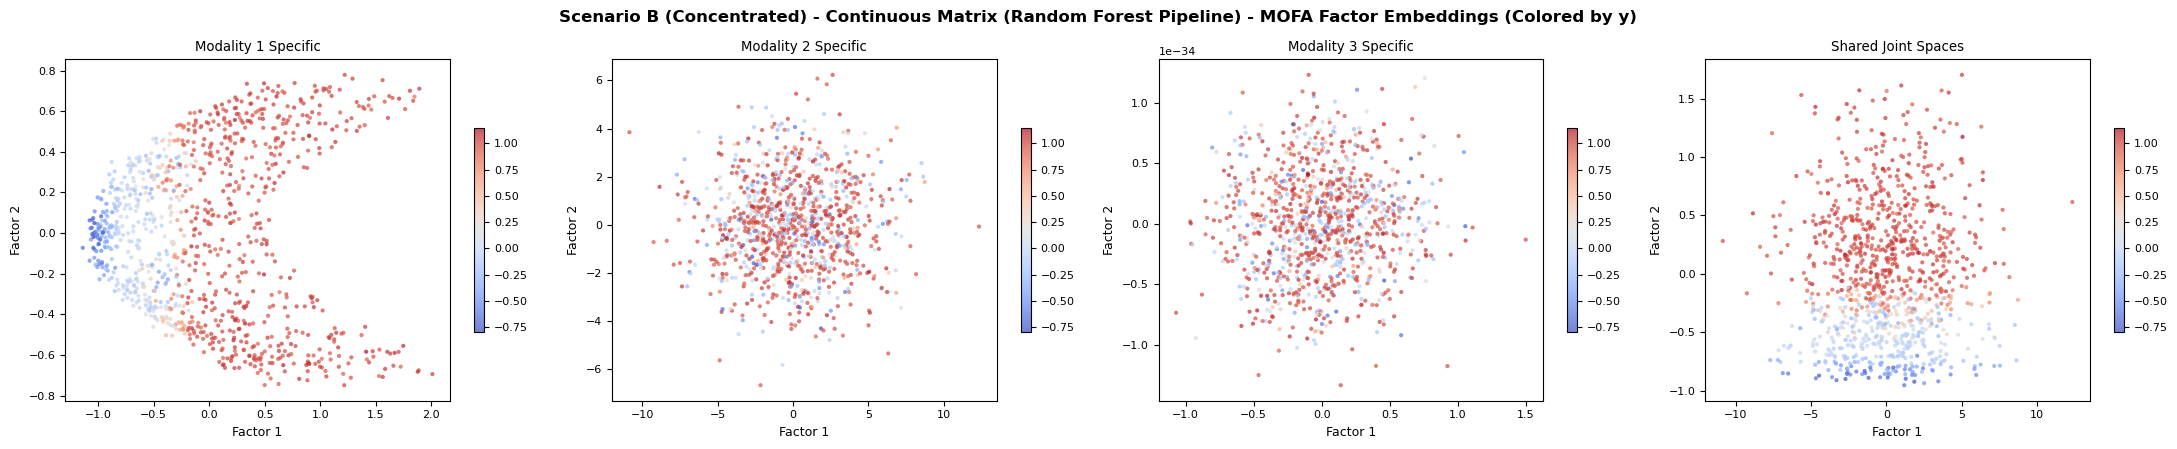


--- Scenario B (Concentrated) - Continuous Matrix Downstream Performance Analysis Table ---
|                    |   Test Non-linear R2 (Random Forest) |
|:-------------------|-------------------------------------:|
| PCA: Modality 1    |                            0.928183  |
| PCA: Modality 2    |                           -0.0793885 |
| PCA: Modality 3    |                           -0.022193  |
| PCA: Concatenated  |                           -0.0825756 |
| MOFA: Modality 1   |                            0.965758  |
| MOFA: Modality 2   |                           -0.080889  |
| MOFA: Modality 3   |                           -0.145758  |
| MOFA: Shared Joint |                            0.891221  |




In [ ]:
# 4. Execute downstream analysis tasks across benchmarks
print("\nRunning downstream classification and regression workflows (PCA vs MOFA)...")
run_random_forest_analysis(mod1_ac, mod2_ac, mod3_ac, y_ac, "Scenario A (Distributed) - Continuous Matrix", is_discrete=False)
run_random_forest_analysis(mod1_ad, mod2_ad, mod3_ad, y_ad, "Scenario A (Distributed) - Discrete Matrix", is_discrete=True)
run_random_forest_analysis(mod1_bc, mod2_bc, mod3_bc, y_bc, "Scenario B (Concentrated) - Continuous Matrix", is_discrete=False)
run_random_forest_analysis(mod1_bd, mod2_bd, mod3_bd, y_bd, "Scenario B (Concentrated) - Discrete Matrix", is_discrete=True)

print("\nRunning alternative downstream evaluation using KMeans integration (PCA only)...")
run_kmeans_analysis(mod1_ac, mod2_ac, mod3_ac, y_ac, "Scenario A (Distributed) - Continuous Matrix", is_discrete=False)
run_kmeans_analysis(mod1_ad, mod2_ad, mod3_ad, y_ad, "Scenario A (Distributed) - Discrete Matrix", is_discrete=True)
run_kmeans_analysis(mod1_bc, mod2_bc, mod3_bc, y_bc, "Scenario B (Concentrated) - Continuous Matrix", is_discrete=False)
run_kmeans_analysis(mod1_bd, mod2_bd, mod3_bd, y_bd, "Scenario B (Concentrated) - Discrete Matrix", is_discrete=True)

---

## Task 2 - Real data of your choice

Pick a public multi-modal dataset with:
- At least two views.
- At least one categorical covariate (subtype, treatment group, tissue type, mutation status, or similar).

Fit MOFA and MOFA/PCA on each single view, then compare their performance on a downstream task using the evaluation strategy from Task 1. Are there any conclusions that can be drawn from the multi-modal model that cannot be drawn from the single-view models?